# Document Alignment
### Complete # TODO

In [2]:
# Imports
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Step 1: Read Tempalate and Scanned Image

In [3]:
# Define the path to the reference image file using os.path.join for cross-platform compatibility
refFilename = os.path.join("images", "form.jpg")

# Read the reference image in color mode
im1 = None # TODO

# Convert the reference image from BGR to RGB format
im1 = None # TODO

# Define the path to the image to be aligned using os.path.join for cross-platform compatibility
imFilename = os.path.join("images", "scanned-form.jpg")

# Read the image to be aligned in color mode
im2 = None # TODO

# Convert the image to be aligned from BGR to RGB format
im2 = None # TODO


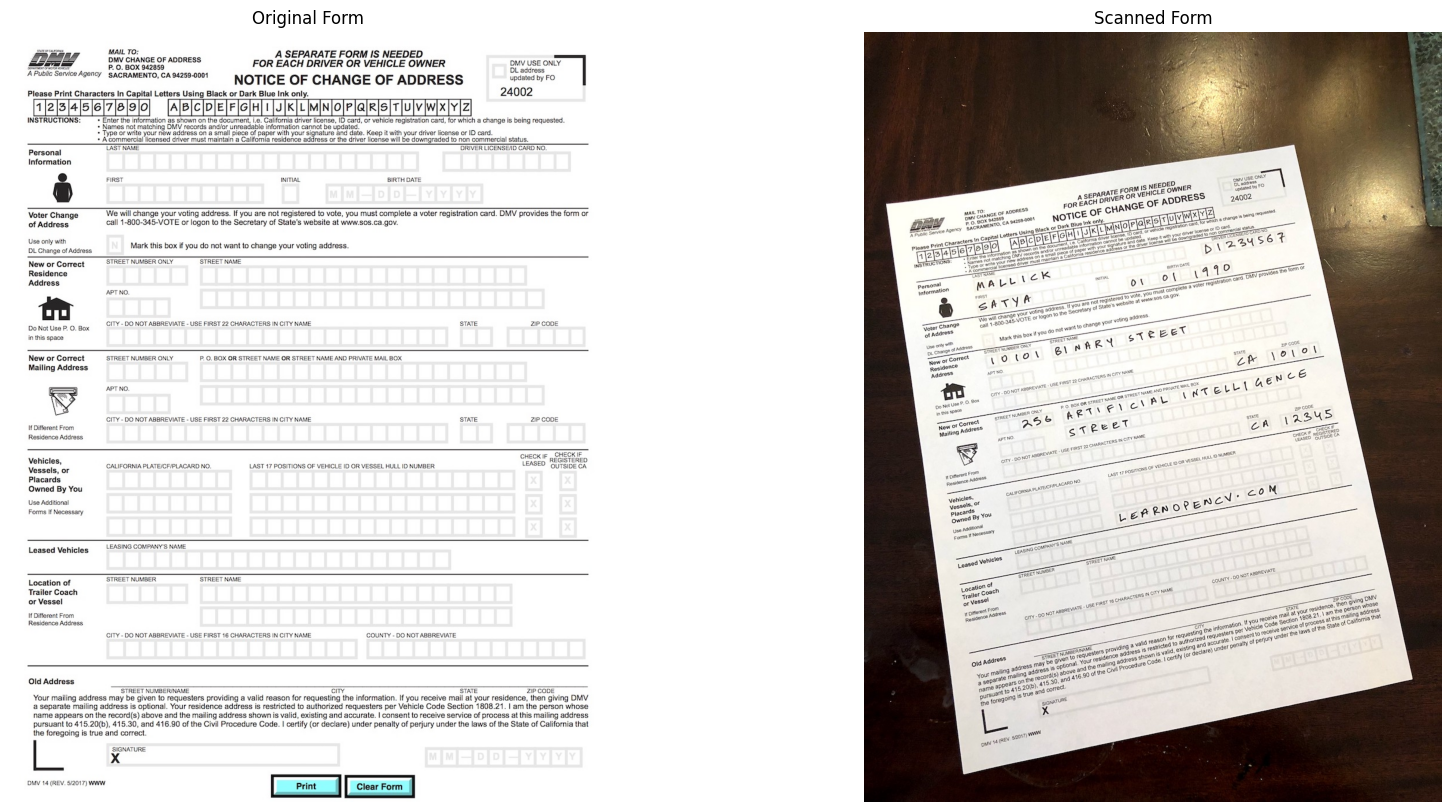

In [ ]:
# Display Images
# TODO

## Step 2: Find keypoints in both Images

Think of keypoints as corner points that are stable under image transformations

In [ ]:
# Convert images to grayscale
im1_gray = None # TODO
im2_gray = None # TODO


# Detect ORB features using OpenCV and compute descriptors.
MAX_NUM_FEATURES = 500
orb = None # TODO
keypoints1, descriptors1 = None # TODO
keypoints2, descriptors2 = None # TODO


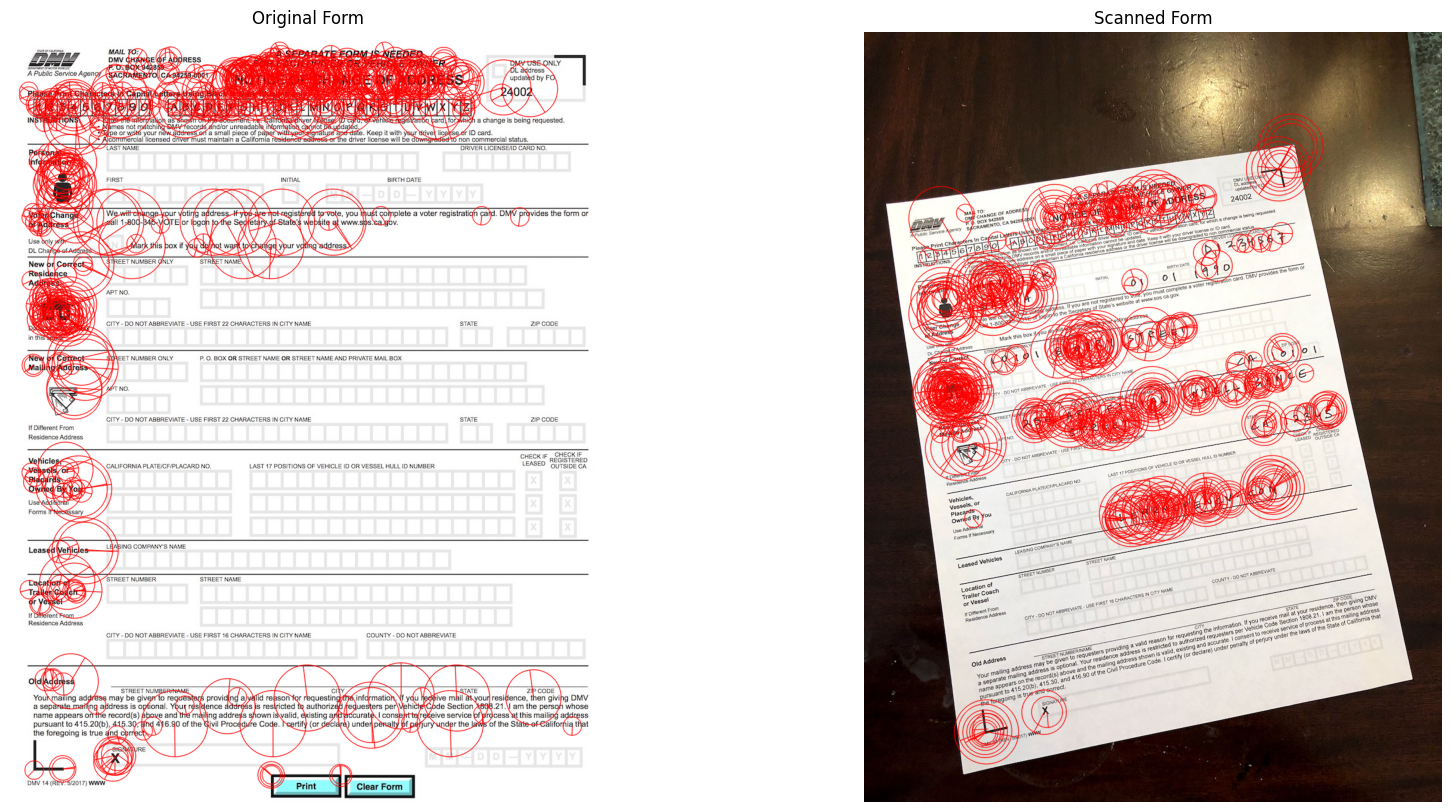

In [ ]:
# Display
im1_display = cv2.drawKeypoints(
    im1,
    keypoints1,
    outImage=np.array([]),
    color=(255, 0, 0),
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
)

im2_display = cv2.drawKeypoints(
    im2,
    keypoints2,
    outImage=np.array([]),
    color=(255, 0, 0),
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
)

# Plot
# TODO

## Step 3 : Match keypoints in the two image

In [ ]:
# Create a DescriptorMatcher object with the BRUTEFORCE_HAMMING algorithm.
# This matcher is used to compare feature descriptors and find the best matches.
matcher = None # TODO

# Match the feature descriptors from two images.
# The match() function finds the best matches between descriptors1 and descriptors2.
# The resulting matches are stored in a list.
matches = list(matcher.match(descriptors1, descriptors2, None))

# Sort the matches based on their distance.
# The distance represents how similar the matched descriptors are.
# Sorting in ascending order (reverse=False) means the best matches (lowest distance) come first.
matches.sort(key=lambda x: x.distance, reverse=False)

# Determine the number of good matches to keep.
# Here, we keep the top 10% of matches.
numGoodMatches = int(len(matches) * 0.1)

# Slice the sorted matches to keep only the top 'numGoodMatches'.
matches = matches[:numGoodMatches]


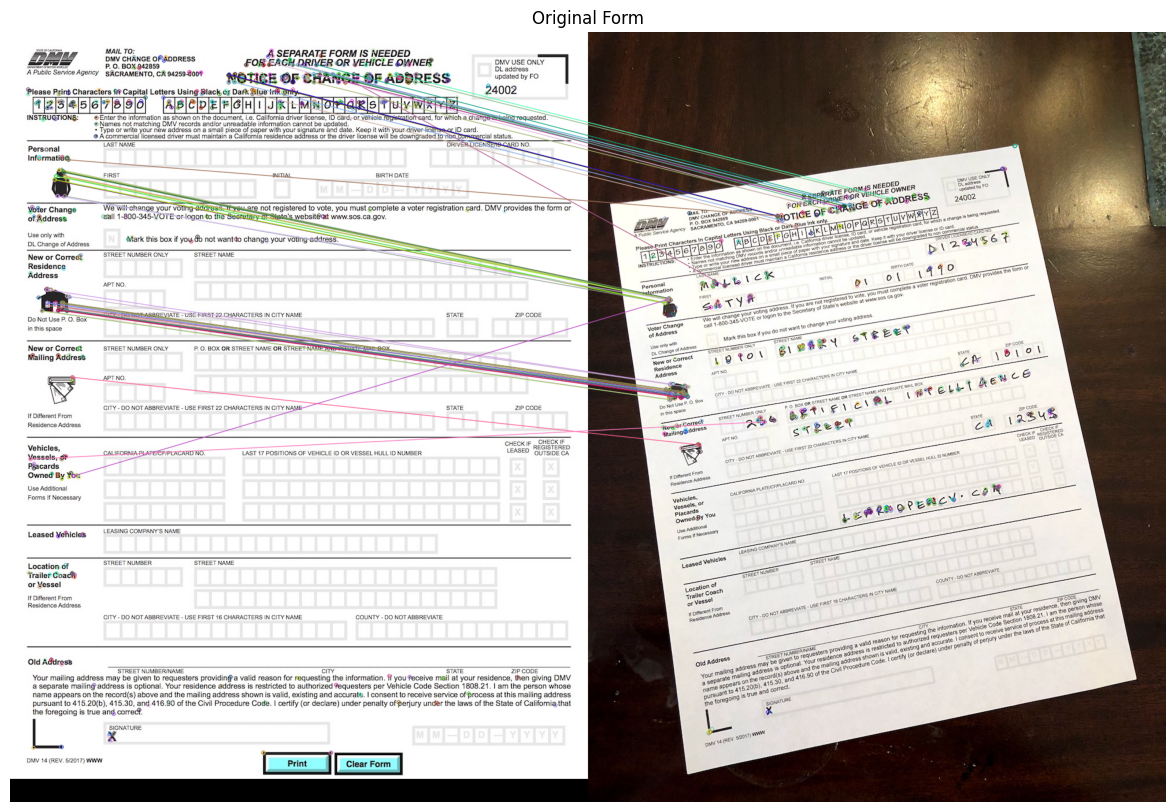

In [ ]:
# Draw top matches
im_matches = cv2.drawMatches(im1, keypoints1, im2, keypoints2, matches, None)

# Display im_matches
# TODO

## Step 4:  Find Homography



In [8]:
# Extract location of good matches
points1 = np.zeros((len(matches), 2), dtype=np.float32)
points2 = np.zeros((len(matches), 2), dtype=np.float32)

for i, match in enumerate(matches):
    points1[i, :] = keypoints1[match.queryIdx].pt
    points2[i, :] = keypoints2[match.trainIdx].pt

# Find homography
h, mask = cv2.findHomography(points2, points1, cv2.RANSAC)

## Step 5: Warp image

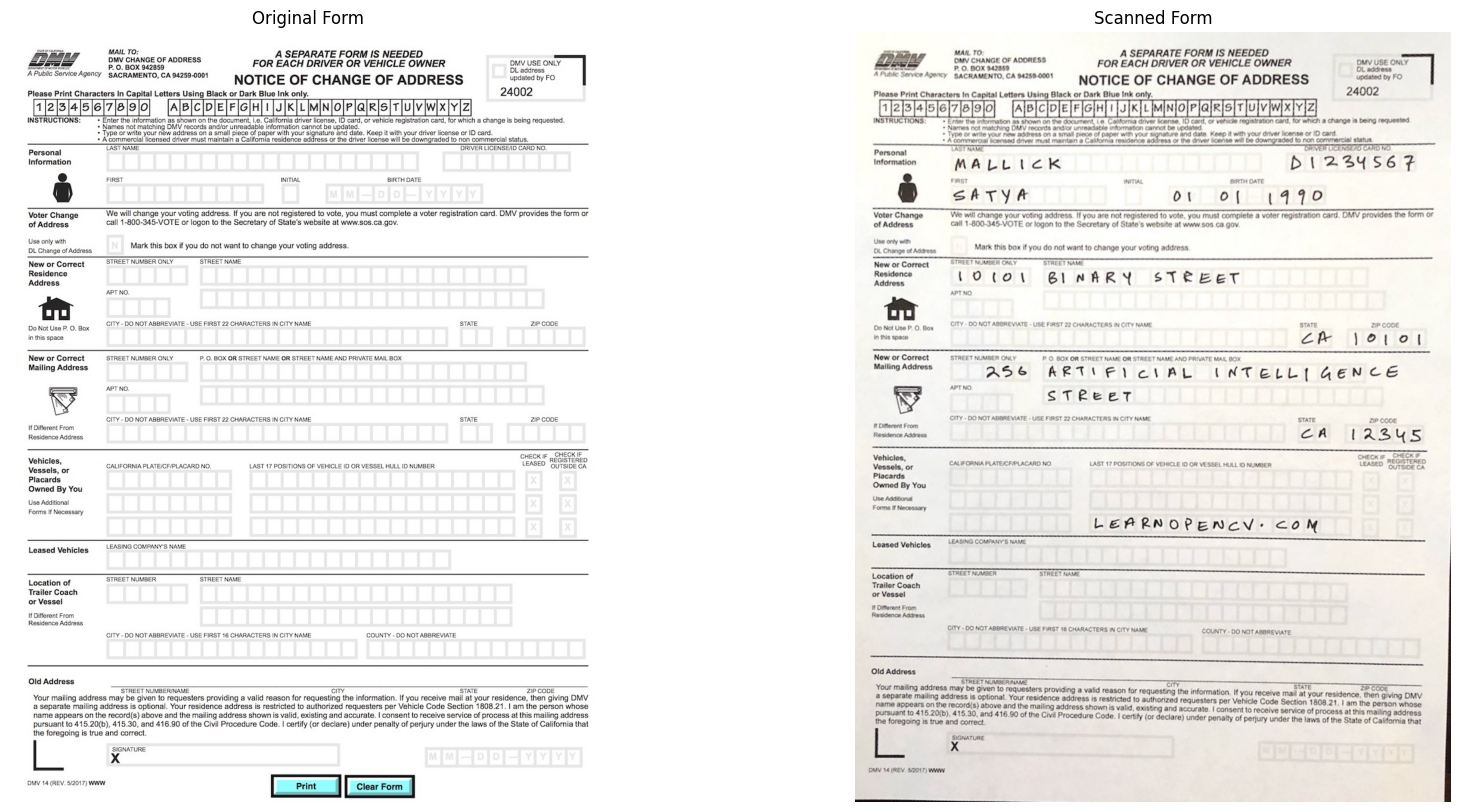

In [ ]:
# Use homography to warp image
height, width, channels = im1.shape
im2_reg = cv2.warpPerspective(im2, h, (width, height))

# Display results
# TODO